<div style='font-size: 30px; color: #000000;background-color: #9BEBA5;border: 3px solid black;text-align: center;'>
<div><b>Inductive learning <br> for indoor positioning systems </b></div>
</div>

### Table of contents
0. [Environment setup](#environment-setup)
1. [Graph construction](#graph-construction)
2. [Optimization](#optimization)
3. [Training](#training)
4. [Results](#results)

___

# 0. Environment setup

## Module loading

In [81]:
import os
import sys
import time
import glob
import json
import ast
import re
import importlib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import itertools 
from itertools import product
import optuna

sys.path.append(os.path.abspath('../src'))

# Custom libraries
import indoorloc_enums
indoorloc_enums = importlib.reload(indoorloc_enums)
import indoorloc_data
indoorloc_data = importlib.reload(indoorloc_data)
import indoorloc_models
indoorloc_models = importlib.reload(indoorloc_models)
import indoorloc_vizs
indoorloc_vizs = importlib.reload(indoorloc_vizs)

import indoorloc_data as ildata
from indoorloc_data import (
    IndoorLocDataset, 
    IndoorLocResults, 
    IndoorLocGraphDataLoader, 
    IndoorLocPreprocessor, 
    IndoorLocGraphData
)
import indoorloc_vizs as ilvizs
import indoorloc_models as ilmodels
from indoorloc_models import (
    SAGERegressor,
    GNNRegressionTrainer
)

## Environment information

System characteristics and CUDA availability check.

In [2]:
ilvizs.EnvironmentInfo().show()


##################################################
	ENVIRONMENT INFORMATION
##################################################

Operating System: Linux
CPU: AMD Ryzen 5 2600 Six-Core Processor
RAM: 15.56 GB
--------------------------------------------------
Selected device cuda
CUDA version: 12.6
Number of available GPUs: 1
GPU 0: NVIDIA GeForce RTX 2060
--------------------------------------------------


----

# 1. Data preprocessing and graph construction

Data preprocessing and graph construction for each dataset from the grid’s parameter combinations.

Available datasets:
* **UJIIndoorLoc**: 'UJI1',
* **UTSIndoorLoc**: 'UTS1',
* **SODIndoorLoc**: 'SOD01', 'SOD02', 'SOD06',
* **TUTDatasets**: 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5'

Available parameters:
* `normalization`: 'lineal', 'powed'
* `pca_components`: Between 0.0 and 1.0
* `distance_metric`: 'manhattan', 'cosine'
* `n_neighbors`: At least 1 is required
* `graph_scheme`: 'transductive', 'inductive'

In [59]:
# Select datasets
dataset_selection = ['SOD01']
datasets = {name: name for name in dataset_selection}

# Generate parameter combinations
parameter_grid = {
    'normalization': ['powed'],
    'pca_components': [0.95],
    'distance_metric': ['cosine'],
    'n_neighbors': [1, 3, 5, 7, 9]
}

parameter_combinations = list(product(
    *parameter_grid.values()
))

# For each dataset and parameter combination, generate graph data
graph_datas = {}
for dataset in tqdm(datasets, desc="Datasets"):
    graph_datas[dataset] = []
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    for norm, pca_components, metric, n_neighbors in tqdm(
        parameter_combinations, 
        desc=f"Creating Graph Datas"
    ):
        # Load dataset
        df_original = IndoorLocDataset(
            dataset_structure=dataset_structure,
            path=f'../data/{dataset}/{dataset}', 
            header=None
        )

        # Preprocess dataset
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=norm,
            pca_components=pca_components
        )

        # Construct graph
        graph_data_tranductive = IndoorLocGraphData().create_data_loader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'metric': metric, 
                'k': n_neighbors,
                'scheme': 'transductive'
            }
        )
        graph_data_inductive = IndoorLocGraphData().create_data_loader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'metric': metric, 
                'k': n_neighbors,
                'scheme': 'inductive'
            }
        )

        # Append graph data
        graph_datas[dataset].append({
            'parameters':{
                'pca_components': pca_components,
                'normalization': norm,
                'metric': metric,
                'n_neighbors': n_neighbors,
            },
            'transductive': graph_data_tranductive,
            'inductive': graph_data_inductive}
        )


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Creating Graph Datas:   0%|          | 0/5 [00:00<?, ?it/s]

Example of graph data encapsulated in the `PyTorch Geometric Data` object for the regression task.

In [60]:
graph_datas['SOD01'][3]['transductive'].reg

Data(num_nodes=1795, val_mask=[1795], train_mask=[1795], test_mask=[1795], val_size=0.2, x=[1795, 12], num_features=12, edge_index=[2, 16602], k=7, y=[1795, 2], y_scaler=MinMaxScaler(), num_classes=0)

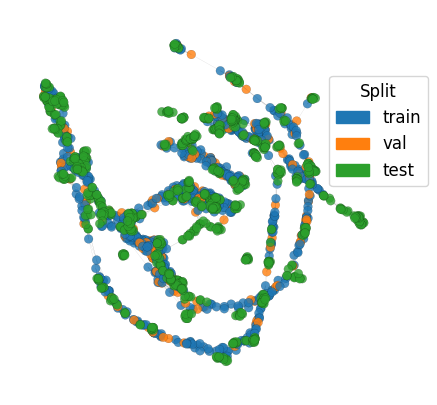

In [78]:
gvizs = indoorloc_vizs.GraphVisualizer()
gvizs.draw_graph(graph_datas['SOD01'][3]['transductive'].reg, scheme="transductive")

In [40]:
graph_datas['SOD01'][0]['inductive'].reg

{'train': Data(num_nodes=764, x=[764, 13], num_features=12, edge_index=[2, 1342], k=1, y=[1795, 2], y_scaler=MinMaxScaler(), num_classes=0),
 'val': Data(num_nodes=191, x=[191, 13], num_features=12, edge_index=[2, 318], k=1, y=[1795, 2], y_scaler=MinMaxScaler(), num_classes=0),
 'test': Data(num_nodes=840, x=[840, 13], num_features=12, edge_index=[2, 1652], k=1, y=[1795, 2], y_scaler=MinMaxScaler(), num_classes=0)}

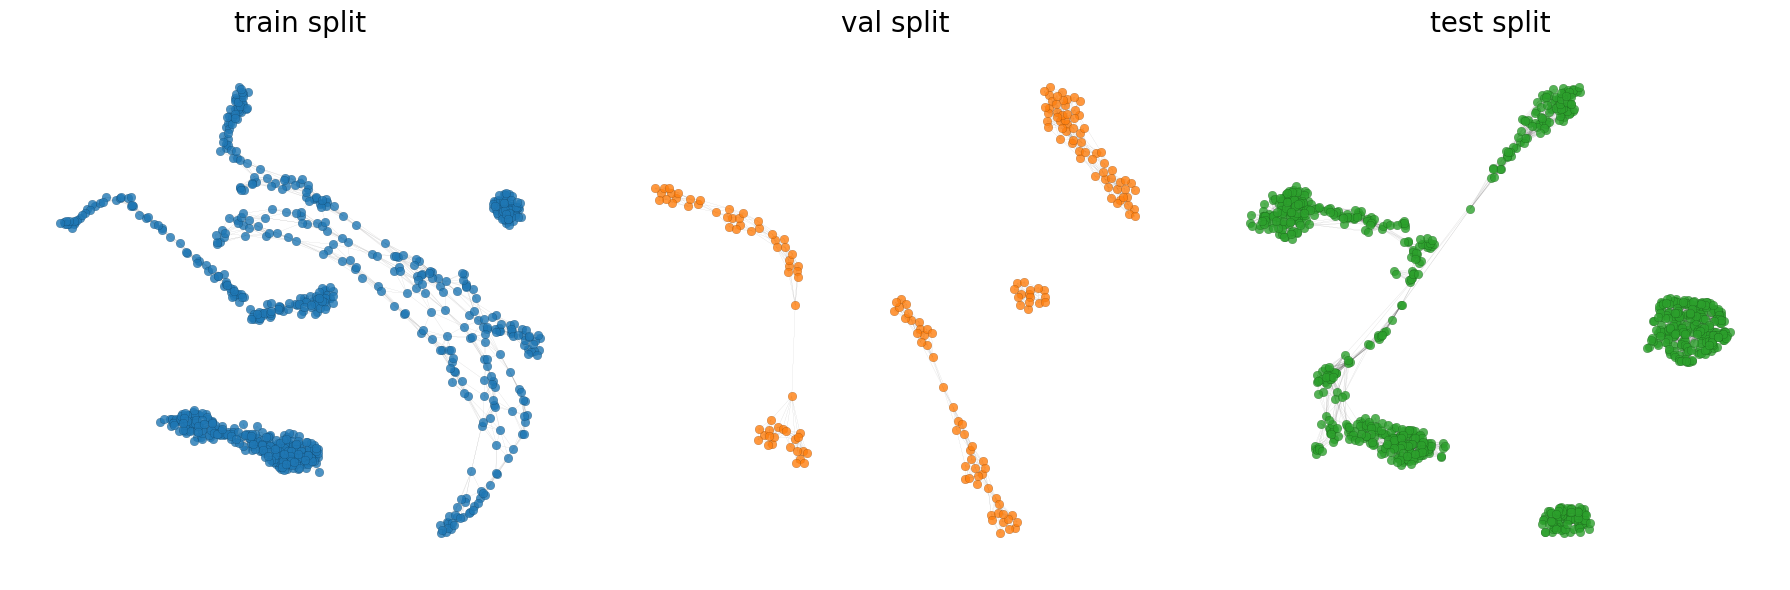

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 

splits = ['train', 'val', 'test']
split_colors = {
    "train": "tab:blue",
    "val": "tab:orange",
    "test": "tab:green"
}
graph_objs = [
    graph_datas['SOD01'][3]['inductive'].reg['train'],
    graph_datas['SOD01'][3]['inductive'].reg['val'],
    graph_datas['SOD01'][3]['inductive'].reg['test']
]

gvizs = indoorloc_vizs.GraphVisualizer()
for ax, split, gdata in zip(axes, splits, graph_objs):
    gvizs.draw_graph(gdata, color=split_colors[split], ax=ax) 
    ax.set_title(f"{split} split", fontsize=20)

plt.tight_layout()
plt.show()